In [1]:
from UTILS import Zmin, Zmax, Zmid, zacceptance_min, zacceptance_max
from matplotlib import pyplot as plt
import numpy as np
import os
import sys

/home/adriano/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [2]:
# ===> ANALYZE SCURVE

In [22]:
outputfile = "tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK"

In [23]:
Tramp1     = 11.2
wait_ramp1 = 121.5 + Tramp1

Tramp2     = 11.2 + wait_ramp1
wait_ramp2 = 121.5 + Tramp2

Tramp3     = 11.2 + wait_ramp2
wait_ramp3 = 121.5 + Tramp3

In [24]:
# Make Plot Nicer
def plotter_nicer():
    plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
    plt.xlabel("bias", loc = 'right', fontsize = 18)
    
    plt.grid()
    plt.minorticks_on()
    plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
    plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
    plt.ylim(-1.1,1.1)
    #plt.xlim(-3, 3)
    
    plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
    #plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
    plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
    #plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
    plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
    plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

In [25]:
def get_annihilations(output, bias):
    f = np.load(output)
    R = f["position"]
    t = f["Time"]

    m = np.isfinite(t)
    z = R[m, 2]
    t = t[m]

    z_up   = zacceptance_max - 1e-3
    z_down = zacceptance_min + 1e-3

    def counts(tmin=None, tmax=None):
        mt = np.ones_like(t, dtype=bool)
        if tmin is not None: mt &= (t > tmin)
        if tmax is not None: mt &= (t < tmax)
        nup   = np.sum((z >= z_up)   & mt)
        ndown = np.sum((z <= z_down) & mt)
        return nup, ndown

    def asym(nup, ndown):
        n = nup + ndown
        if n == 0:
            return np.nan, np.nan
        A = (ndown - nup) / n
        dA = np.sqrt(np.abs(1 - A**2) / n)
        return A, dA

    # totale (t finito)
    A, dA = asym(*counts())

    # segmenti: (tmin, tmax)
    windows = {
        "A0":  (0,        Tramp1),
        "A0b": (Tramp1,   wait_ramp1),
        "A1":  (wait_ramp1, Tramp2),
        "A1b": (Tramp2,   wait_ramp2),
        "A2":  (wait_ramp2, Tramp3),
        "A2b": (Tramp3,   None),
    }

    (A0, dA0)   = asym(*counts(*windows["A0"]))
    (A0b, dA0b) = asym(*counts(*windows["A0b"]))
    (A1, dA1)   = asym(*counts(*windows["A1"]))
    (A1b, dA1b) = asym(*counts(*windows["A1b"]))
    (A2, dA2)   = asym(*counts(*windows["A2"]))
    (A2b, dA2b) = asym(*counts(*windows["A2b"]))

    return [A0, A1, A2, A, A0b, A1b, A2b], [dA0, dA1, dA2, dA, dA0b, dA1b, dA2b]

In [26]:
import pandas as pd
from scipy.optimize import curve_fit

def linear(x,m,q):
    return m*x + q

def shift(m,q):
    return -q/m


cols = [
    "run", "bias", "type_ramp",
    "segment1", "err_segment1",
    "segment2", "err_segment2",
    "segment3", "err_segment3",
    "segment4", "err_segment4"
]

df_onlyramps = pd.read_csv(
    "../comparison_simulation_data/data_onlyramp.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)

df_onlywait = pd.read_csv(
    "../comparison_simulation_data/data_onlywait.txt",
    comment="#",
    sep=r"\s+",
    names=cols
)


##################################################
# SIMULATION, Load the Data

files = os.listdir("output/")

# get all the simulation files relative to a configuration
outputs = [f"output/" + item for item in files if f"{outputfile}" in item]
print("Outputs files: \n", outputs)

simulation_dataset = {}

# create containers for Asymmetries
A0,   A1,  A2, At  = [],[],[],[]
A0b,   A1b,  A2b   = [],[],[]
dA0, dA1, dA2, dAt = [],[],[],[]
dA0b, dA1b, dA2b   = [],[],[]

biases = []

# get the asymetries for each individual segment
for output in outputs:
    print("-"*20)
    bias = output.split("_")[8].replace(".npz","") # get the bias
    A, dA = get_annihilations(output, bias)

    A0.append(A[0])
    A1.append(A[1])
    A2.append(A[2])
    At.append(A[3])
    A0b.append(A[4])
    A1b.append(A[5])
    A2b.append(A[6])
    
    dA0.append(dA[0])
    dA1.append(dA[1])
    dA2.append(dA[2])
    dAt.append(dA[3])
    dA0b.append(dA[4])
    dA1b.append(dA[5])
    dA2b.append(dA[6])

    #print(bias, f"{A[0]:.2}",  f"{dA[0]:.2f}")
    #print(bias, f"{A[1]:.2f}", f"{dA[1]:.2f}")
    #print(bias, f"{A[2]:.2f}", f"{dA[2]:.2f}")

    biases.append( float( bias.replace("p",".").replace("g","") ))

biases = np.array(biases)
#print(biases)

At = np.array(At)
dAt = np.array(dAt)
A0 = np.array(A0)
A1 = np.array(A1)
A2 = np.array(A2)
A0b = np.array(A0)
A1b = np.array(A1b)
A2b = np.array(A2b)
A0 = np.array(A0)
dA1 = np.array(dA1)
dA2 = np.array(dA2)
dA0b = np.array(dA0)
dA1b = np.array(dA1b)
dA2b = np.array(dA2b)

Outputs files: 
 ['output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_-0p5g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_0p75g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_1p25g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_-0p37g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_-0p25g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_-0p75g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_0p25g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_-1p25g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_0p0g.npz', 'output/tau_69.01s_theta_45_axial_7.72mK_transv_15.64mK_0p5g.npz']
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------
--------------------


# Compute the Metric, Chiquare between data and simulation

In [45]:
from scipy.interpolate import CubicSpline
idx = np.argsort(biases)

# Spline of simulation
if not np.isnan(A1[idx]).any():
    simulation_2nd = CubicSpline(biases[idx], A1[idx])
if not np.isnan(A2[idx]).any():
    simulation_3rd = CubicSpline(biases[idx], A2[idx])
if not np.isnan(A1b[idx]).any():
    simulation_2nd_boiloff = CubicSpline(biases[idx], A1b[idx])
if not np.isnan(A2b[idx]).any():
    simulation_3rd_boiloff = CubicSpline(biases[idx], A2b[idx])

def chisq_mean(simulation, x, y, dy):
    x  = np.asarray(x, float)
    y  = np.asarray(y, float)
    dy = np.asarray(dy, float)

    yhat = simulation(x)
    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(dy) & (dy > 0)
    return np.mean(((y[mask] - yhat[mask]) / dy[mask])**2)

def compute_segment_chisq(df, segment, simulation):
    mask = df["type_ramp"] == "short"

    popt, _ = curve_fit(
        linear,
        df["bias"][mask],
        df[f"segment{segment}"][mask]
    )

    x = df["bias"][mask] - shift(popt[0], popt[1])
    y = df[f"segment{segment}"][mask]
    dy = df[f"err_segment{segment}"][mask]

    return chisq_mean(simulation, x, y, dy)

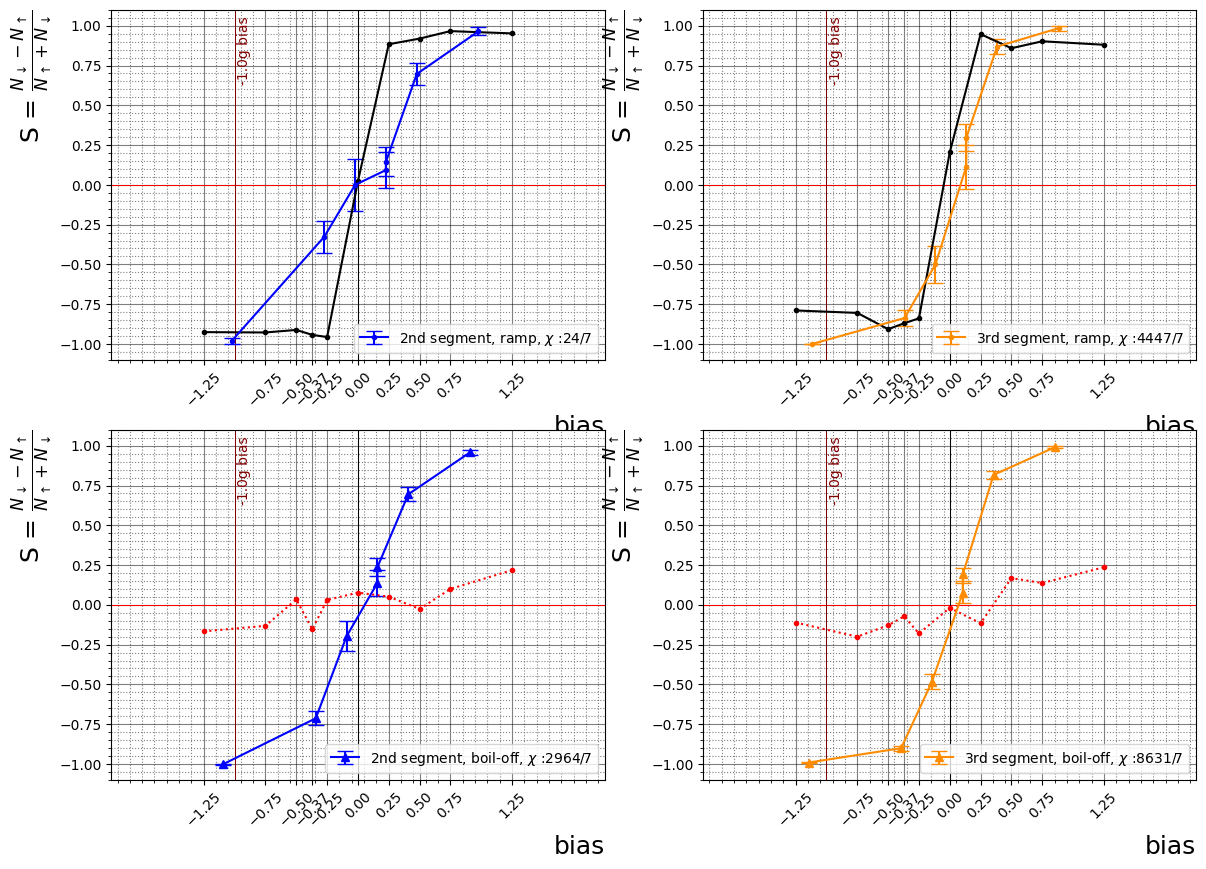

In [51]:
idx = np.argsort(biases)
plt.figure(1, figsize = (14,10))

plt.subplot(2,2,1)
#plt.suptitle("2nd segment")
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], A1[idx],  marker = ".", linestyle = "-", markersize = 6,color = "black", capsize = 4)
# DATASET 2025
mask = df_onlyramps['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment2'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment2'][mask],
             df_onlyramps['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  2, simulation_2nd):.0f}/{mask.sum()}")

plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,2)
# SIMULATION
plotter_nicer()
plt.errorbar(biases[idx], A2[idx],  marker = ".", linestyle = "-", markersize = 6, color = "black", capsize = 4)
popt,pcovm = curve_fit(linear, df_onlyramps['bias'][mask] , df_onlyramps['segment3'][mask])
plt.errorbar(df_onlyramps['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlyramps['segment3'][mask],
             df_onlyramps['err_segment3'][mask], 
             linestyle = "-", 
             markersize = 6 ,
             marker = '.', 
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, ramp, $\chi$ :{compute_segment_chisq(df_onlyramps,  3, simulation_3rd):.0f}/{mask.sum()}")
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()


plt.subplot(2,2,3)
# SIMULATION
plt.errorbar(biases[idx], A1b[idx], marker = ".", linestyle = "dotted", markersize = 6,color = "red", capsize = 4)
#dataset with boil-off
mask = df_onlywait['type_ramp' ] == 'short'
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment2'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment2'][mask],
             df_onlywait['err_segment2'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "blue", 
             label = f"2nd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff):.0f}/{mask.sum()}")
plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.subplot(2,2,4)
# SIMULATION
plt.errorbar(biases[idx], A2b[idx], marker = ".", linestyle = "dotted", markersize = 6,  color = "red",capsize = 4)
#dataset with boil-off
popt,pcovm = curve_fit(linear, df_onlywait['bias'][mask] , df_onlywait['segment3'][mask])
plt.errorbar(df_onlywait['bias'][mask] - shift(popt[0], popt[1]), 
             df_onlywait['segment3'][mask],
             df_onlywait['err_segment3'][mask],
             linestyle = "-", 
             markersize = 6 ,
             marker = '^',
             capsize = 6,
             color = "darkorange", 
             label = f"3rd segment, boil-off, $\chi$ :{compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff):.0f}/{mask.sum()}")


plotter_nicer()
plt.xticks(biases[idx], rotation = 45, fontsize = 10)
plt.xlim(-2,+2)
plt.legend()

plt.savefig(f"output/figures/output_scurve/{outputfile}_Scurve.png", bbox_inches = 'tight')

# Save Metric

In [52]:
data = np.load("output/" + outputfile + "_0p0g.npz")
d = dict(data)

chisq_list = []

if not np.isnan(A1[idx]).any():
    chisq_list.append(compute_segment_chisq(df_onlyramps, 2, simulation_2nd))
else:
    chisq_list.append(99999)
if not np.isnan(A2[idx]).any():
    chisq_list.append(compute_segment_chisq(df_onlyramps, 3, simulation_3rd))
else:
    chisq_list.append(99999)
if not np.isnan(A1b[idx]).any():
    chisq_list.append(compute_segment_chisq(df_onlywait,  2, simulation_2nd_boiloff))
else:
    chisq_list.append(99999)
if not np.isnan(A2b[idx]).any():
    chisq_list.append(compute_segment_chisq(df_onlywait,  3, simulation_3rd_boiloff))
else:
    chisq_list.append(99999)

d["Chisq_S"] = np.array(chisq_list)

np.savez("output/" + outputfile + "_0p0g.npz", **d)
print("GOODCOFFEE")

GOODCOFFEE
